# Gated Recurrent Unit (GRU) - IMDb Sentiment Analysis

This project applies a Gated Recurrent Unit (GRU) network to perform binary sentiment classification on the IMDb movie review dataset. The notebook mirrors the previous RNN and LSTM projects so the architectural differences can be compared fairly. 


## 1. Import Required Libraries

Import the required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
print(tf.__version__)

2.21.0


## 2. Load the IMDb Dataset

Load the official TensorFlow IMDb dataset.

In [2]:
num_words=20000
maxlen=250
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=num_words)
word_index=imdb.get_word_index()
reverse_word_index={v+3:k for k,v in word_index.items()}
reverse_word_index.update({0:'<PAD>',1:'<START>',2:'<UNK>',3:'<UNUSED>'})

## 3. Explore the Dataset

Inspect review lengths and class balance.

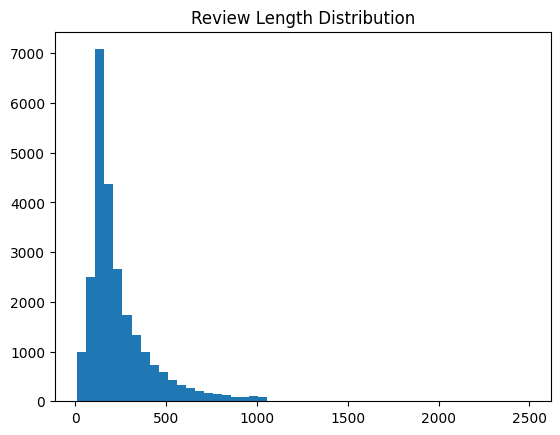

Positive: 12500
Negative: 12500


In [3]:
plt.hist([len(x) for x in X_train],bins=50)
plt.title('Review Length Distribution')
plt.show()
print('Positive:',np.sum(y_train))
print('Negative:',len(y_train)-np.sum(y_train))

## 4. Create Validation Set

Split the training data.

In [4]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

## 5. Preprocess the Data

Pad sequences to a fixed length.

In [5]:
X_train=pad_sequences(X_train,maxlen=maxlen)
X_val=pad_sequences(X_val,maxlen=maxlen)
X_test=pad_sequences(X_test,maxlen=maxlen)

## 6. Build the GRU Model

Construct the model.

In [6]:
model=Sequential([Embedding(input_dim=num_words,output_dim=128),GRU(64),Dense(32,activation='relu'),Dense(1,activation='sigmoid')])
model.build(input_shape=(None,maxlen))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,599,361 (9.92 MB)

 Trainable params: 2,599,361 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

Train using EarlyStopping.

In [7]:
early=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=15,batch_size=64,callbacks=[early])
best_epoch=np.argmin(history.history['val_loss'])+1
print(best_epoch)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 116ms/step - accuracy: 0.7663 - loss: 0.4632 - val_accuracy: 0.8620 - val_loss: 0.3304
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9176 - loss: 0.2158 - val_accuracy: 0.8562 - val_loss: 0.3946
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.9582 - loss: 0.1178 - val_accuracy: 0.8768 - val_loss: 0.3534
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.9741 - loss: 0.0738 - val_accuracy: 0.8742 - val_loss: 0.4198
1


## 8. Training Curves

Visualize learning curves.

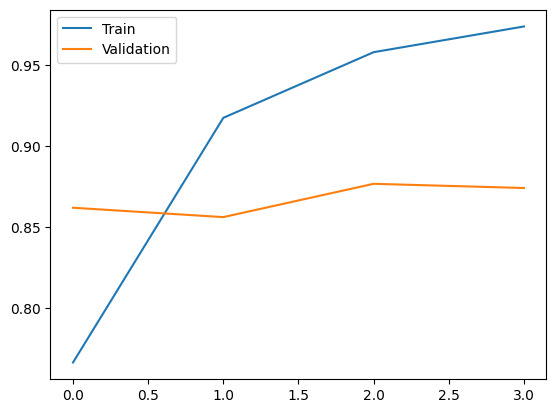

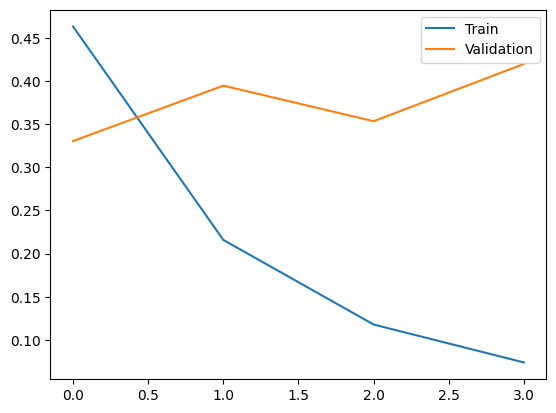

In [8]:
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.legend();plt.show()
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend();plt.show()

## 9. Evaluate the Model

Evaluate on the test set.

In [9]:
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print(loss,acc)
predictions=(model.predict(X_test,verbose=0)>0.5).astype(int).ravel()

0.3394117057323456 0.8565599918365479


## 10. Classification Report

Generate evaluation metrics.

In [10]:
print(classification_report(y_test,predictions,digits=4))

              precision    recall  f1-score   support

           0     0.8227    0.9090    0.8637     12500
           1     0.8983    0.8042    0.8486     12500

    accuracy                         0.8566     25000
   macro avg     0.8605    0.8566    0.8562     25000
weighted avg     0.8605    0.8566    0.8562     25000



## 11. Confusion Matrix

Visualize prediction performance.

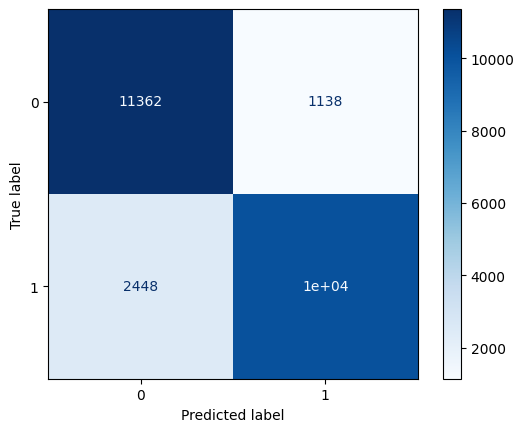

In [11]:
cm=confusion_matrix(y_test,predictions)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

## 12. Error Analysis

Review several misclassified examples.

In [12]:
mis=np.where(predictions!=y_test)[0][:5]
for idx in mis:
 review=' '.join(reverse_word_index.get(i,'?') for i in X_test[idx] if i!=0)
 print('='*80)
 print('True:',y_test[idx],'Pred:',predictions[idx])
 print(review[:1500],'...')

True: 0 Pred: 1
<START> hollywood had a long love affair with bogus arabian nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs anachronistic slang and slapstick it's a truly crop of corn and pretty near intolerable today it was nominated for its imaginative special effects which are almost <UNK> in this day and age consisting mainly of trick photography the only outstanding positive feature which survives is its beautiful color and clarity sad to say of the many films made in this genre few of them come up to alexander <UNK> original thief of baghdad almost any other arabian nights film is superior to this one though it's a loser ...
True: 1 Pred: 0
<START> inspired by hitchcock's strangers on a train concept of two men swapping murders in exchange for getting rid of the two people messing up their lives throw <UNK> from the train is an original 

# 13. Discussion

The GRU demonstrated strong performance on the IMDb sentiment classification task, achieving a **test accuracy of 85.66%** while maintaining balanced classification performance across both sentiment classes. Using the same dataset, preprocessing pipeline and training strategy as the previous RNN and LSTM implementations allowed the observed performance differences to be attributed primarily to the recurrent architecture rather than experimental variations.

Compared with the vanilla RNN, the GRU substantially improved generalization by incorporating gating mechanisms that regulate the flow of sequential information. However, the GRU produced slightly lower performance than the LSTM on this dataset. This suggests that the additional memory cell available in the LSTM provided a measurable advantage when modelling long movie reviews containing extended contextual dependencies.

The remaining classification errors were largely associated with reviews containing mixed opinions, gradual sentiment transitions or subtle language that is inherently difficult to model. Although the GRU offers a simpler recurrent architecture with fewer gating operations than the LSTM, it was still able to capture long-range contextual information effectively while maintaining competitive predictive performance.

# 14. Key Findings

- The GRU achieved a **test accuracy of 85.66%**, representing a substantial improvement over the SimpleRNN baseline while remaining competitive with the LSTM implementation.
- Validation performance remained stable throughout training, indicating effective optimization and good generalization to unseen data.
- Precision, recall and F1-score were well balanced across both sentiment classes, demonstrating reliable classification performance without a significant class bias.
- Compared with the LSTM, the GRU achieved slightly lower predictive performance, suggesting that the additional memory cell of the LSTM provided a measurable benefit for modelling longer contextual dependencies in IMDb reviews.
- The results demonstrate that GRUs provide an effective compromise between architectural simplicity and predictive performance, making them a practical alternative when computational efficiency is an important consideration.

# 15. Conclusion

This project demonstrates that Gated Recurrent Units are capable of learning meaningful sequential representations for natural language sentiment classification while maintaining a simpler architecture than Long Short-Term Memory networks. The GRU significantly outperformed the vanilla Recurrent Neural Network and achieved competitive performance on the IMDb dataset.

Although the LSTM remained the strongest-performing architecture in this comparison, the GRU illustrates that comparable performance can be achieved using a reduced gating mechanism. This project completes the recurrent neural network series by highlighting the trade-off between model complexity, computational efficiency and predictive performance, providing a solid foundation for transitioning to more advanced sequence modelling architectures.